# Introduction

This project serves as an in-depth analysis of the diversity of arthropods from the fossil record. It will consider three major areas of potential variation in diversity: geologic age, paleoenvironment, and taxonomic groupings. Many factors will be considered for each of these areas, including the number of occurences and the distribution of various taxonomic groups such as classes and orders. 

The data is obtained from the [Paleobiology Database](https://paleobiodb.org/#/), which possesses a publicly available data service API. The data was obtained using the [occs/list operation](https://paleobiodb.org/data1.2/occs/list_doc.html), which can be used to retreive a list of fossil occurrences. Many additional fields were chosen beyond the default ones to be used in later analysis. The full list of various parameters, available fields, descriptions for these, and other information are available to be browsed on their website. After retrieving the data from the API, it is written into a CSV file for reuse.

# Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

The data is read from the CSV file created from the data collection notebook and viewed. Note that while there are 40 columns, only a select few will be important in analysis, and thus only those columns need to be adequately prepared.

In [2]:
pd.set_option("display.max_columns", None)

fossil_data = pd.read_csv("../data/raw/all_fossils_raw.csv")
fossil_data.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,accepted_rank,accepted_no,early_interval,late_interval,max_ma,min_ma,reference_no,phylum,class,order,family,genus,environment,tectonic_setting,geology_comments,cc,state,county,latlng_basis,latlng_precision,altitude_value,altitude_unit,geogscale,geogcomments,paleomodel,geoplate,paleoage,paleolng,paleolat,time_bins
0,1021171,occ,NaN,NaN,125073,Sinocoosella typica n. gen. n. sp.,species,NaN,NaN,Sinocoosella typica,species,225377,Guzhangian,NaN,500.500,497.00,40544,Arthropoda,Trilobita,Ptychopariida,Crepicephalidae,Sinocoosella,slope,NaN,NaN,CN,Guizhou,Wanshan,estimated from map,minutes,NaN,NaN,outcrop,E of Gaolouping,gplates,611,mid,84.98,-12.42,Miaolingian
1,957062,occ,25159.0,NaN,112002,Juxathyris bisulcata,species,191225.0,NaN,Juxathyris bisulcata,species,191219,Wuchiapingian,NaN,259.857,254.14,13997,Brachiopoda,Rhynchonellata,Athyridida,Athyrididae,Juxathyris,coastal indet.,NaN,NaN,CN,Guizhou,NaN,based on nearby landmark,3,NaN,NaN,outcrop,NaN,gplates,611,mid,104.97,-17.08,Lopingian
2,2067604,occ,NaN,NaN,278507,Peronella radiciformis,species,NaN,NaN,Peronella radiciformis,species,522256,Late Jurassic,NaN,161.500,143.10,94337,Porifera,Calcarea,Stellispongiida,Stellispongiidae,Peronidella,marine indet.,NaN,NaN,DE,Baden-Württemberg,NaN,based on nearby landmark,seconds,NaN,NaN,small collection,"Location simply given as ""Randen; Würtemberg"" ...",gplates,305,mid,21.85,30.75,Late Jurassic
3,1338828,occ,NaN,NaN,180820,Kockelella variabilis,species,NaN,NaN,Kockelella variabilis,species,337076,Ludfordian,NaN,425.000,422.70,59405,Chordata,Conodonta,Ozarkodinida,Kockelellidae,Kockelella,offshore ramp,NaN,NaN,US,Nevada,Eureka,estimated from map,seconds,NaN,NaN,NaN,NaN,gplates,101,mid,-100.80,-19.39,Ludlow
4,401157,occ,NaN,NaN,38455,Pseudoatrypa cf. devoniana,species,313908.0,NaN,Pseudoatrypa devoniana,species,313907,Givetian,NaN,387.950,382.31,10310,Brachiopoda,Rhynchonellata,Atrypida,Atrypidae,Pseudoatrypa,marine indet.,NaN,NaN,US,Ohio,NaN,based on nearby landmark,minutes,NaN,NaN,local area,"Various quarries in the vicinity of Sylvania, ...",gplates,101,mid,-50.76,-31.00,Middle Devonian


In [3]:
rows, columns = fossil_data.shape
print("Number of rows:", rows, "\nNumber of columns:", columns)

Number of rows: 241997 
Number of columns: 40


First, the data types of the important features should be checked to see if they're applicable for analysis.

In [4]:
pd.set_option("display.max_rows", None)

fossil_data.dtypes

occurrence_no         int64
record_type             str
reid_no             float64
flags                   str
collection_no         int64
identified_name         str
identified_rank         str
identified_no       float64
difference              str
accepted_name           str
accepted_rank           str
accepted_no           int64
early_interval          str
late_interval           str
max_ma              float64
min_ma              float64
reference_no          int64
phylum                  str
class                   str
order                   str
family                  str
genus                   str
environment             str
tectonic_setting        str
geology_comments        str
cc                      str
state                   str
county                  str
latlng_basis            str
latlng_precision        str
altitude_value      float64
altitude_unit           str
geogscale               str
geogcomments            str
paleomodel              str
geoplate            

Everything seems to be in order.

Next, whitespace will be stripped from string values to avoid values varying in only slight ways.

In [5]:
str_cols = fossil_data.select_dtypes(str).columns

fossil_data[str_cols] = fossil_data[str_cols].apply(lambda x: x.str.strip(), axis=0)

space_found = fossil_data[str_cols][fossil_data[str_cols] == " "].any(axis=0).any()
if not space_found:
    print("No whitespace present.")

No whitespace present.


Key features such as accepted_name, environment, and class should not have bad values, and any such values will be removed.

The values of the accepted_name column are analyzed for potential bad values. For example, if one entry were simply "?", it would show up at the end of the sorted values. Likewise, if an entry were "N/A", it would have a length of 3 and thus could be identified by sorting string lengths.

In [6]:
cols = {"name": fossil_data["accepted_name"], "length": fossil_data["accepted_name"].str.len()}
name_lengths = pd.DataFrame(cols).sort_values(by="name")

name_lengths.iloc[np.r_[0:5, len(name_lengths)-5:len(name_lengths)]]

,name,length
118085,Aacocrinus enigmaticus,22
223669,Aalenirhynchia walkeri,22
155953,Aaptochiton pustulosus,22
176169,Aatotomus placochton,20
177102,Aayemenaytcheia paragranulata,29
184051,Zygrhablithus bijugatus,23
57203,Zygrhablithus bijugatus,23
139794,Zygrhablithus bijugatus,23
55776,Zygrhablithus bijugatus,23
229726,Zymus succinicola,17


In [7]:
name_lengths = name_lengths.sort_values(by="length")

name_lengths.iloc[np.r_[0:5, len(name_lengths)-5:len(name_lengths)]]

,name,length
58749,Ano ona,7
25405,Ano ona,7
35408,Hra nie,7
179737,Ano ona,7
180642,Ano ona,7
237895,Aulacostephanus (Aulacostephanoceras) autissio...,54
188174,Aulacostephanus (Aulacostephanoceras) autissio...,54
39386,Fusiturricula (Crenaturricula) crenatospira do...,55
102168,Hoplitoplacenticeras (Hoplitoplacenticeras) co...,57
138838,Pulvinocephalus (Pulvinocephalus) steinachensi...,58


No unusual values are found. However, this doesn't mean there are none. Unfortunately, there are simply far too many unique values in the column to check if there are definitively any bad values. Therefore, possible bad values such as "UNKOWN" and "NA" will be checked in case they are present.

The other important columns are also checked.

In [8]:
fossil_data["class"].unique()

<StringArray>
[         'Trilobita',     'Rhynchonellata',           'Calcarea',
          'Conodonta', 'NO_CLASS_SPECIFIED',  'Coccolithophyceae',
         'Gastropoda',           'Mammalia',      'Strophomenata',
        'Cephalopoda',
 ...
       'Reptilipedia',      'Pezizomycetes',  'Ustilaginomycetes',
    'Helicoplacoidea',       'Dinocaridida',          'Remipedia',
    'Lepidocystoidea',            'Agnatha',         'Clitellata',
       'Cribricyatha']
Length: 172, dtype: str

In [9]:
fossil_data["time_bins"].unique()

<StringArray>
[      'Miaolingian',         'Lopingian',     'Late Jurassic',
            'Ludlow',   'Middle Devonian',       'Pleistocene',
          'Pliocene',            'Eocene',           'Miocene',
     'Pennsylvanian',       'Guadalupian',    'Early Jurassic',
   'Late Ordovician',         'Paleocene',         'Oligocene',
    'Early Devonian',   'Late Cretaceous',        'Cisuralian',
  'Early Cretaceous',      'Terreneuvian',     'Late Triassic',
   'Middle Jurassic',     'Mississippian',     'Late Devonian',
                 '-',   'Middle Triassic',  'Early Ordovician',
        'Llandovery', 'Middle Ordovician',          'Series 2',
          'Holocene',    'Early Triassic',           'Pridoli',
         'Furongian',           'Wenlock']
Length: 35, dtype: str

The value "NO_CLASS_SPECIFIED" is clearly not a valid value. The other taxonomic features have similar values, and will also be removed. "-" from time_bins is also not valid. The other columns are in order. All missing values will be replaced with np.nan so that they can be easily dropped from the DataFrame.

In [10]:
missing_values = ["", "-", "NA", "na", "N/A", "n/a", "UNKNOWN", "NOT_FOUND", 
                  "NO_PHYLUM_SPECIFIED", "NO_CLASS_SPECIFIED", "NO_ORDER_SPECIFIED", 
                  "NO_FAMILY_SPECIFIED", "NO_GENUS_SPECIFIED", 
                  "NO_ACCEPTED_NAME_SPECIFIED"]

fossil_data = fossil_data.replace(missing_values, np.nan)

subset = ["accepted_name", "max_ma", "min_ma", "phylum", "class", "order", "family", 
          "genus", "time_bins", "environment"]

fossil_data = fossil_data.dropna(subset=subset, how="any")

rows, columns = fossil_data.shape
print("Number of rows:", rows, "\nNumber of columns:", columns)

Number of rows: 180012 
Number of columns: 40


In [11]:
num_missing_values = len(fossil_data[subset][fossil_data[subset].isna().any(axis=1)])

print("Remaining missing values:", num_missing_values)

Remaining missing values: 0


Potential duplicate rows are dropped.

In [12]:
fossil_data = fossil_data.drop_duplicates()

rows, columns = fossil_data.shape
print("Number of rows:", rows, "\nNumber of columns:", columns)

Number of rows: 180012 
Number of columns: 40


Bad values are also checked for the maximum and minimum age columns.

In [13]:
fossil_data[["min_ma", "max_ma"]].describe()

,min_ma,max_ma
count,180012.000000,180012.000000
mean,169.131261,174.494451
std,157.001711,157.867401
min,0.000000,0.011700
25%,23.040000,27.300000
50%,137.050000,143.100000
75%,266.900000,274.400000
max,530.700000,538.800000


It appears the oldest fossils date to over 500 million years ago. This would place them in the Cambrian period, which fits current theories on the origins of arthropods.

The environment column contains over 60 unique environments. This is far more specific than analysis warrents. Grouping them into more broad categories would be better suited. Some cases could plausibly fit into more than one grouping.

In [14]:
fossil_data["environment"].unique()

<StringArray>
[                               'slope',
                       'coastal indet.',
                        'marine indet.',
                        'offshore ramp',
              'shallow subtidal indet.',
                   'terrestrial indet.',
                     'carbonate indet.',
                'open shallow subtidal',
             'reef, buildup or bioherm',
                  'basinal (siliceous)',
                   'lacustrine - large',
                  'perireef or subreef',
                  'deep subtidal shelf',
                            'peritidal',
                                 'cave',
                             'offshore',
                       'fluvial indet.',
                  'coarse channel fill',
                'interdistributary bay',
                  'basinal (carbonate)',
                    'deep-water indet.',
                   'deep subtidal ramp',
                      'offshore indet.',
                          'estuary/bay',
  

In [15]:
environment_mapping = {

    # ============================================================
    # Deep Marine
    # ============================================================
    "basinal (carbonate)": "Deep Marine",
    "basinal (siliciclastic)": "Deep Marine",
    "basinal (siliceous)": "Deep Marine",
    "deep-water indet.": "Deep Marine",
    "slope": "Deep Marine",
    "submarine fan": "Deep Marine",
    "deep subtidal shelf": "Deep Marine",
    "deep subtidal ramp": "Deep Marine",
    "deep subtidal indet.": "Deep Marine",
    "offshore": "Deep Marine",
    "offshore indet.": "Deep Marine",
    "offshore ramp": "Deep Marine",

    # ============================================================
    # Shallow Marine
    # ============================================================
    "offshore shelf": "Shallow Marine",
    "shallow subtidal indet.": "Shallow Marine",
    "open shallow subtidal": "Shallow Marine",
    "peritidal": "Shallow Marine",
    "sand shoal": "Shallow Marine",

    # ============================================================
    # Marine Indeterminate
    # ============================================================
    "marine indet.": "Marine Indeterminate",
    "carbonate indet.": "Marine Indeterminate",

    # ============================================================
    # Reef
    # ============================================================
    "reef, buildup or bioherm": "Reef",
    "perireef or subreef": "Reef",
    "slope/ramp reef": "Reef",
    "basin reef": "Reef",
    "platform/shelf-margin reef": "Reef",
    "intrashelf/intraplatform reef": "Reef",

    # ============================================================
    # Coastal / Estuarine
    # ============================================================
    "transition zone/lower shoreface": "Coastal/Estuarine",
    "shoreface": "Coastal/Estuarine",
    "foreshore": "Coastal/Estuarine",
    "coastal indet.": "Coastal/Estuarine",
    "marginal marine indet.": "Coastal/Estuarine",
    "estuary/bay": "Coastal/Estuarine",
    "lagoonal": "Coastal/Estuarine",
    "lagoonal/restricted shallow subtidal": "Coastal/Estuarine",
    "paralic indet.": "Coastal/Estuarine",

    # ============================================================
    # Deltaic
    # ============================================================
    "prodelta": "Deltaic",
    "delta front": "Deltaic",
    "deltaic indet.": "Deltaic",
    "delta plain": "Deltaic",
    "interdistributary bay": "Deltaic",
    "fluvial-deltaic indet.": "Deltaic",
    "lacustrine delta front": "Deltaic",
    "lacustrine deltaic indet.": "Deltaic",
    "lacustrine delta plain": "Deltaic",
    "lacustrine interdistributary bay": "Deltaic",

    # ============================================================
    # Fluvial
    # ============================================================
    "fluvial indet.": "Fluvial",
    '"channel"': "Fluvial",
    "fine channel fill": "Fluvial",
    "coarse channel fill": "Fluvial",
    "channel lag": "Fluvial",
    "alluvial fan": "Fluvial",
    "crevasse splay": "Fluvial",
    "levee": "Fluvial",

    # ============================================================
    # Floodplain / Wetland
    # ============================================================
    "dry floodplain": "Floodplain/Wetland",
    '"floodplain"': "Floodplain/Wetland",
    "wet floodplain": "Floodplain/Wetland",
    "mire/swamp": "Floodplain/Wetland",

    # ============================================================
    # Lacustrine
    # ============================================================
    "lacustrine indet.": "Lacustrine",
    "lacustrine - large": "Lacustrine",
    "lacustrine - small": "Lacustrine",
    "fluvial-lacustrine indet.": "Lacustrine",
    "pond": "Lacustrine",
    "crater lake": "Lacustrine",

    # ============================================================
    # Terrestrial Indeterminate
    # ============================================================
    "terrestrial indet.": "Terrestrial Indeterminate",

    # ============================================================
    # Karst / Cave
    # ============================================================
    "cave": "Karst/Cave",
    "karst indet.": "Karst/Cave",
    "sinkhole": "Karst/Cave",
    "fissure fill": "Karst/Cave",

    # ============================================================
    # Aeolian
    # ============================================================
    "eolian indet.": "Aeolian",
    "dune": "Aeolian",
    "loess": "Aeolian",
    "interdune": "Aeolian",

    # ============================================================
    # Glacial
    # ============================================================
    "glacial": "Glacial",

    # ============================================================
    # Specialized / Other
    # ============================================================
    "spring": "Specialized/Other",
    "tar": "Specialized/Other"
}

fossil_data["general_environment"] = fossil_data["environment"].map(environment_mapping)

In [16]:
fossil_data["general_environment"].unique()

<StringArray>
[              'Deep Marine',         'Coastal/Estuarine',
      'Marine Indeterminate',            'Shallow Marine',
 'Terrestrial Indeterminate',                      'Reef',
                'Lacustrine',                'Karst/Cave',
                   'Fluvial',                   'Deltaic',
                   'Aeolian',         'Specialized/Other',
        'Floodplain/Wetland',                   'Glacial']
Length: 14, dtype: str

Finally, certain important columns are renamed for better intelligibility.

In [17]:
new_names = {"environment": "specific_environment", "cc": "country", "time_bins": "epoch"}
fossil_data = fossil_data.rename(new_names, axis=1)
fossil_data[["specific_environment", "country", "epoch"]].head()

,specific_environment,country,epoch
0,slope,CN,Miaolingian
1,coastal indet.,CN,Lopingian
2,marine indet.,DE,Late Jurassic
3,offshore ramp,US,Ludlow
4,marine indet.,US,Middle Devonian


In [18]:
fossil_data.to_csv("../data/processed/all_fossils_processed.csv")

In [19]:
arth_data = fossil_data.query("phylum == 'Arthropoda' ")
arth_data.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,accepted_rank,accepted_no,early_interval,late_interval,max_ma,min_ma,reference_no,phylum,class,order,family,genus,specific_environment,tectonic_setting,geology_comments,country,state,county,latlng_basis,latlng_precision,altitude_value,altitude_unit,geogscale,geogcomments,paleomodel,geoplate,paleoage,paleolng,paleolat,epoch,general_environment
0,1021171,occ,NaN,NaN,125073,Sinocoosella typica n. gen. n. sp.,species,NaN,NaN,Sinocoosella typica,species,225377,Guzhangian,NaN,500.50,497.00,40544,Arthropoda,Trilobita,Ptychopariida,Crepicephalidae,Sinocoosella,slope,NaN,NaN,CN,Guizhou,Wanshan,estimated from map,minutes,NaN,NaN,outcrop,E of Gaolouping,gplates,611,mid,84.98,-12.42,Miaolingian,Deep Marine
20,1203372,occ,NaN,NaN,138696,Lina wetteravica,species,NaN,NaN,Lina wetteravica,species,284843,MP 30,NaN,27.30,23.04,50903,Arthropoda,Insecta,Coleoptera,Chrysomelidae,Chrysomela,lacustrine - large,rift,According to the reconstruction of the sedimen...,DE,Nordrhein-Westfalen,NaN,based on nearby landmark,3,NaN,NaN,NaN,"""east of Bonn"" (coordinate based on one Rott o...",gplates,315,mid,10.97,46.13,Oligocene,Lacustrine
39,1539735,occ,NaN,NaN,144466,Hamoderces opilionoides n. gen. n. sp.,species,NaN,NaN,Hamoderces opilionoides,species,430411,Early Cenomanian,NaN,100.50,93.90,74746,Arthropoda,Arachnida,Araneae,Praepholcidae,Hamoderces,terrestrial indet.,NaN,"""...inclusions in the piece are numerous frass...",MM,NaN,NaN,stated in text,seconds,NaN,NaN,NaN,Coordinates for Noije Bum given by Selden et a...,gplates,617,mid,105.50,8.29,Late Cretaceous,Terrestrial Indeterminate
65,215438,occ,NaN,NaN,146857,Asemoblatta danielsi n. sp.,species,NaN,NaN,Asemoblatta danielsi,species,226621,Westphalian D,NaN,309.80,307.40,37094,Arthropoda,Insecta,Blattodea,Archimylacridae,Asemoblatta,interdistributary bay,foreland basin,NaN,US,Illinois,NaN,based on nearby landmark,2,NaN,NaN,local area,"Mostly collected in vicinity of Morris, along ...",gplates,101,mid,-23.47,-4.94,Pennsylvanian,Deltaic
73,1222321,occ,NaN,NaN,120813,Megapodaphis hauniae,species,289292.0,NaN,Megapodaphis hauniae,species,223758,Priabonian,NaN,37.71,33.90,52274,Arthropoda,Insecta,Hemiptera,Aphididae,Megapodaphis,terrestrial indet.,NaN,NaN,PL,NaN,NaN,NaN,2,NaN,NaN,local area,"Coordinates based on vicinity of Gdansk, Poland.",gplates,302,mid,22.00,47.92,Eocene,Terrestrial Indeterminate


In [20]:
rows, columns = arth_data.shape
print("Number of rows:", rows, "\nNumber of columns:", columns)

Number of rows: 24179 
Number of columns: 41


In [21]:
arth_data.to_csv("../data/processed/arthropod_fossils_processed.csv")

# Diversity Across Time

Arthropods have existed since the beginning of the Phanerozoic Eon. However, their diversity today is significantly higher than when they started in the Cambrian. Insects in particular are enormously diverse today and are said to represent 80% of all living species. But how has their diversity changed over the ages? Was their growth linear or exponential?

To start, the number of recorded fossils from each epoch is displayed.

In [44]:
arth_by_epoch = (
    arth_data.groupby("epoch")
      .agg(species_count=("accepted_name", "nunique"), age=("max_ma", "max"))
      .reset_index()
      .sort_values("age", ascending=False)
)

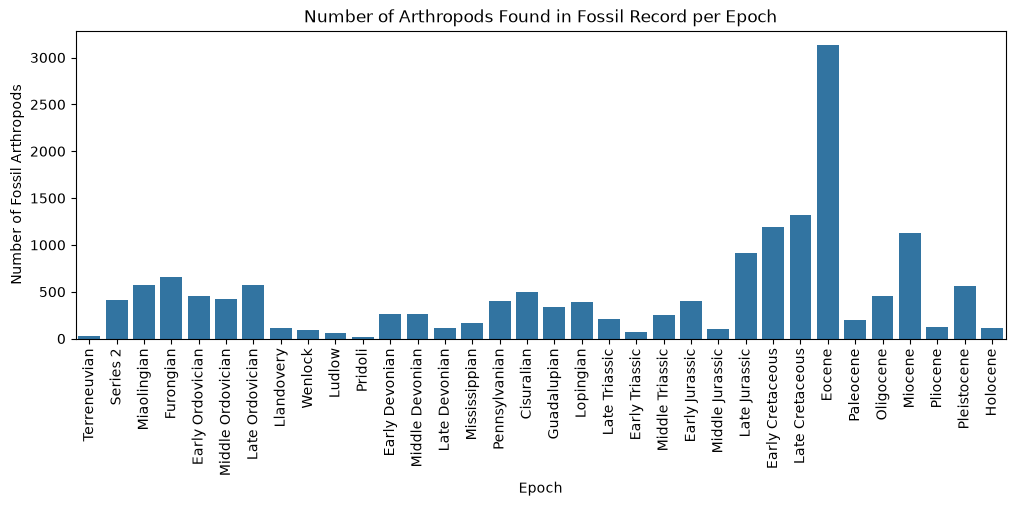

In [45]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x="epoch", y="species_count", data=arth_by_epoch)
ax.set_xlabel("Epoch")
ax.set_ylabel("Number of Fossil Arthropods")
ax.set_title("Number of Arthropods Found in Fossil Record per Epoch")
plt.xticks(rotation=90)
plt.show()

This gives a very interesting result. For some reason, the Eocene has by far the highest number of arthropod species discovered. It's unclear as to why exactly this is. However, it could simply be a sampling bias. The Eocene could have the highest number of arthropods simply because it has more species discovered in general. This could be due to the Eocene just so happening to have more occurences discovered than from other peiods. THe number of species is inspected to confirm this.

In [46]:
species_by_epoch = (
    fossil_data.groupby("epoch")
      .agg(species_count=("accepted_name", "nunique"), age=("max_ma", "max"))
      .reset_index()
      .sort_values("age", ascending=False)
)

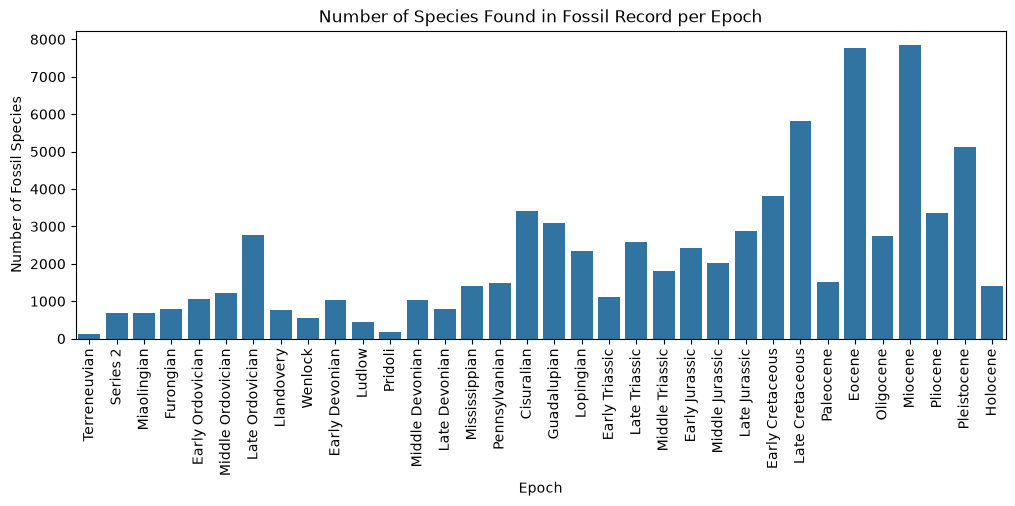

In [47]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x="epoch", y="species_count", data=species_by_epoch)
ax.set_xlabel("Epoch")
ax.set_ylabel("Number of Fossil Species")
ax.set_title("Number of Species Found in Fossil Record per Epoch")
plt.xticks(rotation=90)
plt.show()

Indeed, the Eocene has more discovered species than most other epochs. However, the difference is smaller than the difference for only arthropods. Therefore, there might still be a high proportion of arthropods. This is confirmed below.

In [63]:
combined_by_epoch = arth_by_epoch.join(species_by_epoch, lsuffix="_arth", rsuffix="_all")

combined_by_epoch["ratio"] = combined_by_epoch["species_count_arth"] / combined_by_epoch["species_count_all"]
combined_by_epoch[["epoch_arth", "ratio"]].sort_values("ratio", ascending=False).reset_index(drop=True)

,epoch_arth,ratio
0,Furongian,0.850000
1,Miaolingian,0.834783
2,Series 2,0.596798
3,Early Ordovician,0.434248
4,Eocene,0.403375
5,Middle Ordovician,0.348760
6,Late Jurassic,0.318609
7,Early Cretaceous,0.312598
8,Pennsylvanian,0.273834
9,Middle Devonian,0.258972


This gives an interesting result. Out of 32 epochs, the Eocene has the fifth highest ratio of arthropods to all fossils. The four above it are either from the Cambrian or Ordivician, a time when arthropods dominated the world's biological landscape. This is strong evidence for a genuinely high presence of arthropods in the Eocene compared to other epochs. However, it's still difficult to say confirm this. 

In [75]:
eocene_arth_colls = (
    arth_data[arth_data["epoch"] == "Eocene"]
    .groupby("collection_no")["accepted_name"]
    .nunique().sort_values(ascending=False)
    )

eocene_all_colls = (
    fossil_data[fossil_data["epoch"] == "Eocene"]
    .groupby("collection_no")["accepted_name"]
    .nunique().sort_values(ascending=False)
    )

In [77]:
eocene_arth_colls

collection_no
123927    286
106384    198
124318    118
123419    102
110735    100
124073     92
109625     89
123762     72
120813     68
122997     66
120811     52
123959     49
113749     45
123757     44
106381     43
113621     42
123850     41
123960     38
129227     36
110737     34
124205     32
123766     31
123493     30
124624     27
123420     24
155693     23
113470     23
122591     22
207553     22
123119     21
127170     20
129228     20
207470     19
120814     19
21976      19
123771     18
123215     18
134456     18
123458     17
123870     17
106380     16
122093     16
114060     16
106382     15
127617     14
124463     14
106379     14
123438     14
124530     13
120798     13
122090     13
123936     13
123769     12
123977     12
124273     12
192258     12
147606     12
207556     12
123962     11
146999     11
152022     11
123764     10
123928     10
124517     10
124503     10
121306     10
145128     10
140158     10
124680     10
123862     10
123221

In [76]:
eocene_all_colls

collection_no
123927    286
106384    198
124318    118
123419    102
110735    100
124073     92
109625     89
123762     72
120813     68
122997     66
120811     53
123959     49
90600      48
113749     45
123757     44
8124       43
94830      43
106381     43
113621     42
123850     41
123960     38
129227     36
78567      34
110737     34
124205     32
184107     31
123766     31
205489     30
123493     30
124624     27
205410     27
42636      26
184110     26
81266      25
164232     25
230806     25
123420     24
207112     23
113470     23
155693     23
3494       23
207553     22
122591     22
205485     21
13299      21
123119     21
91115      21
13779      20
129228     20
127170     20
205267     20
81278      20
120814     19
21976      19
205422     19
91606      19
207470     19
3266       18
139020     18
123215     18
134456     18
10703      18
123771     18
16657      17
123458     17
123870     17
205438     17
90471      17
41998      17
75454      17
120798